In [236]:
#Importando bibliotecas

import pandas as pd 
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS

In [65]:
opnioes = pd.read_csv('C:/Users/Dell/Desktop/reclamacoes_consumidor.csv')
opnioes.head(10)

C:\Users\Dell\AppData\Local\Temp\ipykernel_21668\381961494.py:1: DtypeWarning: Columns (5,11) have mixed types. Specify dtype option on import or set low_memory=False.
  opnioes = pd.read_csv('C:/Users/Dell/Desktop/consumer_complaints.csv')


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
0,08/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074
1,08/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080
2,08/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473
3,08/30/2013,Student loan,Non-federal student loan,Repaying your loan,Repaying your loan,NaN,NaN,"Navient Solutions, Inc.",MD,21402,NaN,NaN,Email,08/30/2013,Closed with explanation,Yes,Yes,510326
4,08/30/2013,Debt collection,Credit card,False statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,GA,30106,NaN,NaN,Web,08/30/2013,Closed with explanation,Yes,Yes,511067
5,08/30/2013,Credit card,NaN,Application processing delay,NaN,NaN,NaN,Capital One,NY,12206,NaN,NaN,Phone,09/03/2013,Closed with explanation,Yes,Yes,510098
6,08/30/2013,Credit card,NaN,Credit line increase/decrease,NaN,NaN,NaN,Wells Fargo & Company,AZ,85730,NaN,NaN,Postal mail,09/05/2013,Closed with explanation,Yes,No,511062
7,08/30/2013,Bank account or service,Checking account,Deposits and withdrawals,NaN,NaN,NaN,Bank of America,IL,60660,NaN,NaN,Referral,09/04/2013,Closed with explanation,Yes,No,511116
8,08/30/2013,Bank account or service,Checking account,Deposits and withdrawals,NaN,NaN,NaN,Bank of America,GA,30016,NaN,NaN,Referral,09/04/2013,Closed with explanation,Yes,No,511091
9,09/17/2013,Mortgage,Conventional adjustable mortgage (ARM),"Loan modification,collection,foreclosure",NaN,NaN,NaN,"SunTrust Banks, Inc.",CA,94551,NaN,NaN,Web,09/18/2013,Closed with explanation,Yes,Yes,530602


In [67]:
#Agora vamos entender os tipos das variaveis do nosso dataset
opnioes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555957 entries, 0 to 555956
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date_received                 555957 non-null  object
 1   product                       555957 non-null  object
 2   sub_product                   397635 non-null  object
 3   issue                         555957 non-null  object
 4   sub_issue                     212622 non-null  object
 5   consumer_complaint_narrative  66806 non-null   object
 6   company_public_response       85124 non-null   object
 7   company                       555957 non-null  object
 8   state                         551070 non-null  object
 9   zipcode                       551452 non-null  object
 10  tags                          77959 non-null   object
 11  consumer_consent_provided     123458 non-null  object
 12  submitted_via                 555957 non-null  object
 13 

Durante a análise exploratória, foi identificado que algumas colunas do dataset contêm valores nulos. No entanto, para os objetivos específicos desta análise — focada em contestações de consumidores e sentimentos associados — esses valores ausentes não impactam diretamente os resultados, já que as colunas-chave utilizadas (como consumer_disputed?, company e issue) estão completas ou com cobertura suficiente para garantir uma análise consistente.

In [69]:
#Analise de quais os tipos de reclamações sobre produtos mais recorrents:
opnioes["product"].value_counts()

product
Mortgage                   186475
Debt collection            101052
Credit reporting            91854
Credit card                 66468
Bank account or service     62563
Consumer Loan               20990
Student loan                15839
Payday loan                  3877
Money transfers              3812
Prepaid card                 2470
Other financial service       557
Name: count, dtype: int64

In [71]:
#Vamos analisar agora o retorno de atendimentos das empresas:
opnioes['company_response_to_consumer'].value_counts()

company_response_to_consumer
Closed with explanation            404293
Closed with non-monetary relief     70237
Closed with monetary relief         38262
Closed without relief               17909
Closed                              13399
Closed with relief                   5305
In progress                          3763
Untimely response                    2789
Name: count, dtype: int64

Vemos que a maior parte dos retornos que as empresas dão para os seus clientes, tem uma explicação

In [73]:
# Vamos analisar agora a quantidade de consumidores que contestou o retorno das empresas
contestacao = opnioes['consumer_disputed?'].value_counts()
contestaram = opnioes['company'].loc[opnioes['consumer_disputed?'] == 'Yes'].value_counts()[:10]
naoContestaram = opnioes['company'].loc[opnioes['consumer_disputed?'] == 'No'].value_counts()[:10]

In [77]:
contestacao

consumer_disputed?
No     443823
Yes    112134
Name: count, dtype: int64

Dos 555.957 registros analisados, cerca de 20% (112.134) dos consumidores contestaram a resposta dada pela empresa, enquanto 80% (443.823) não contestaram.
Esse dado indica que, embora a maioria das reclamações tenha sido encerrada sem disputa adicional, uma parcela significativa dos clientes ainda não se sentiu satisfeita com a resposta recebida. Esse grupo pode representar um ponto crítico de insatisfação e merece atenção especial na análise de sentimento e na proposta de melhorias no atendimento.

In [75]:
#Vamos ver agora as empresas onde os consumidores mais contestaram:
contestaram

company
Bank of America                           12480
Wells Fargo & Company                      9644
JPMorgan Chase & Co.                       7716
Equifax                                    6647
Citibank                                   5245
Ocwen                                      5067
Experian                                   3891
TransUnion Intermediate Holdings, Inc.     3824
Nationstar Mortgage                        3157
Capital One                                2935
Name: count, dtype: int64

Nesta análise, identificamos as 10 empresas que mais receberam contestações por parte dos consumidores, ou seja, casos em que o cliente não aceitou a resposta da empresa. O Bank of America novamente lidera a lista, com mais de 12 mil contestações, seguido por Wells Fargo, JPMorgan Chase e Equifax.
Esse cenário pode indicar uma insatisfação recorrente com as soluções oferecidas por essas instituições, mesmo após a resposta inicial. Essas contestações merecem atenção especial, pois podem apontar falhas na comunicação, falta de resolutividade ou até mesmo problemas sistêmicos no atendimento ao cliente.

In [79]:
naoContestaram

company
Bank of America                           43518
Wells Fargo & Company                     32380
Experian                                  27014
JPMorgan Chase & Co.                      26165
Equifax                                   25181
TransUnion Intermediate Holdings, Inc.    21710
Citibank                                  20295
Ocwen                                     15911
Capital One                               12693
Nationstar Mortgage                       10093
Name: count, dtype: int64

Essa informação pode indicar que, nessas instituições, as respostas dadas ao consumidor foram consideradas suficientes na maioria dos casos — o que pode sugerir uma eficiência maior na resolução inicial dos problemas, ou ainda, uma baixa taxa de acompanhamento por parte dos consumidores. Vale investigar se isso está relacionado à qualidade do atendimento, ao tipo de problema ou à percepção do consumidor sobre a efetividade do processo.

<H2>Criando uma nuvem de palavras</H2>

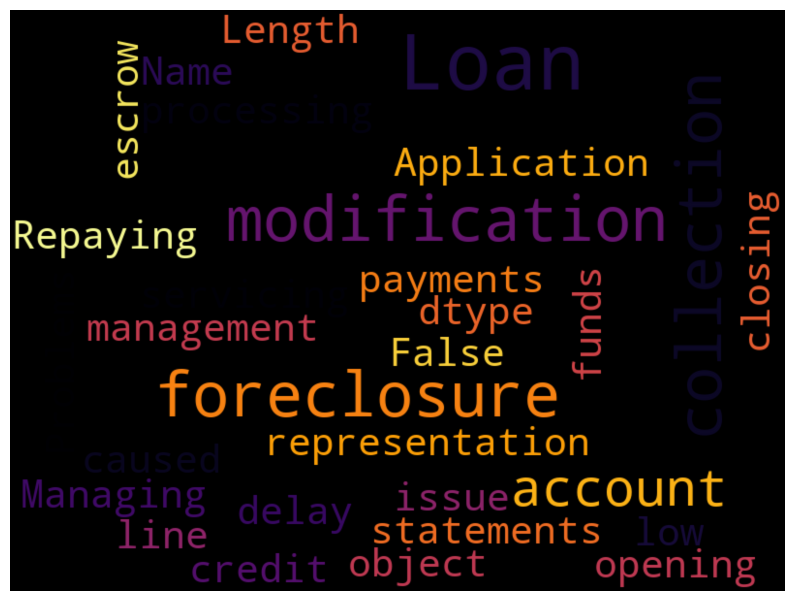

In [91]:
#Este trecho de código gera uma nuvem de palavras (WordCloud) com os termos mais frequentes encontrados na coluna issue,
#filtrando apenas os registros em que os consumidores contestaram a resposta da empresa (consumer_disputed? == 'Yes').

disputas_questao = opnioes['issue'].loc[opnioes['consumer_disputed?'] == 'Yes']
word_cloud = WordCloud(width = 800,
                       height = 600,
                       colormap = 'inferno', 
                       margin = 0,
                       max_words = 2000,  
                       max_font_size = 80,  
                       background_color = "black").generate(str(disputas_questao))

plt.figure(figsize = (10, 15))
plt.imshow(word_cloud, interpolation = "gaussian")
plt.axis("off")
plt.show()

A visualização acima mostra as palavras mais recorrentes nas reclamações em que os consumidores não concordaram com a resposta da empresa. Termos como "foreclosure" (execução hipotecária), "modification" (modificação de empréstimos), "loan" (empréstimo), "account" (conta) e "collection" (cobrança) aparecem em destaque, indicando os principais temas de insatisfação e contestação.
Essa análise qualitativa sugere que os consumidores estão particularmente insatisfeitos com processos relacionados a empréstimos, execuções, modificações contratuais e cobranças, que são temas sensíveis e, muitas vezes, complexos de resolver.

<H2>Preparando os dados textuais para treinar um modelo de machine learning</H2>

Iremos aplicar modelos de machine learning para classificar automaticamente o sentimento dos clientes com base nas transcrições das interações. Serão utilizados os algoritmos Naive Bayes, Decision Tree e Regressão Logistica para realizar a previsão do sentimento, categorizando-o em positivo, negativo ou neutro

In [105]:
# Importação de bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import preprocessing


In [99]:
#Deixando todas as palavras com letras minusculas:
opnioes['issue'] = opnioes['issue'].str.strip().str.lower()

In [107]:
#Agora vamos converter os valores necessários para nossa análise de categóricos para númericos
# Essa codificação permite que o nosso modelo interprete a variável como um alvo binário em tarefas de classificação supervisionada, 
#como prever se uma nova reclamação tem chance de ser contestada pelo consumidor.

label_encoder = preprocessing.LabelEncoder()
opnioes['consumer_disputed']= label_encoder.fit_transform(opnioes['consumer_disputed?'])

opnioes['consumer_disputed'].unique()
# YES = 1
# No = 0


array([1, 0])

In [111]:
opnioes.head(5)

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id,consumer_disputed
0,08/30/2013,Mortgage,Other mortgage,"loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074,1
1,08/30/2013,Mortgage,Other mortgage,"loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080,1
2,08/30/2013,Credit reporting,NaN,incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473,0
3,08/30/2013,Student loan,Non-federal student loan,repaying your loan,Repaying your loan,NaN,NaN,"Navient Solutions, Inc.",MD,21402,NaN,NaN,Email,08/30/2013,Closed with explanation,Yes,Yes,510326,1
4,08/30/2013,Debt collection,Credit card,false statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,GA,30106,NaN,NaN,Web,08/30/2013,Closed with explanation,Yes,Yes,511067,1


<H2>Dividindo o dataset entre dados de treino e dados de teste</H2>

In [192]:
x = opnioes['issue']
y = opnioes['consumer_disputed']
x_train, x_test, y_train, y_test = train_test_split(x,y, stratify=y, test_size=0.25, random_state=42)

<H2>Vetorizando revisão dos textos para numeros</H2>

In [194]:
vec = CountVectorizer(stop_words='english')
x_train = vec.fit_transform(x_train).toarray()
x_test = vec.transform(x_test).toarray()

Essa vetorização é necessária para transformar o texto em uma matriz numérica, facilitando seu uso nos algoritmos de machine learning que iremos aplicar

<H2>Realizando a previsão com algoritmo de Naive Bayes</H2>

In [196]:
from sklearn.naive_bayes import MultinomialNB
modelNB = MultinomialNB()
modelNB.fit(x_train, y_train)

MultinomialNB()

In [198]:
modelNB.score(x_test, y_test)

0.7866393265702568

In [200]:
modelNB.predict(vec.transform(['Communication tactics']))

array([0])

O modelo de Naive Bayes obteve um desempenho de 78.66% de precisão na classificação do sentimento com base nas transcrições. Este resultado indica uma boa capacidade do modelo para identificar o sentimento das interações, embora haja espaço para melhorias

<H2>Arvore de Decisão</H2>

In [202]:
from sklearn.tree import DecisionTreeClassifier
arvore = DecisionTreeClassifier(criterion='entropy', random_state=1)

In [204]:
arvore.fit(x_train,y_train)


DecisionTreeClassifier(criterion='entropy', random_state=1)

In [206]:
arvore.score(x_test,y_test)

0.7983020361177063

In [208]:
arvore.predict(vec.transform(['Managing the loan or lease']))

array([0])

 modelo de Decision Tree obteve um desempenho de 79.83% de precisão na classificação do sentimento das transcrições. Esse resultado é ligeiramente superior ao do Naive Bayes, indicando que a Decision Tree foi mais eficaz na identificação dos sentimentos expressos nas interações

<H2>Regressão Logistica</H2>

In [211]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [213]:
modeloLog = LogisticRegression(max_iter=1000)  # aumenta o número de iterações se precisar
modeloLog.fit(x_train, y_train)

y_pred = modeloLog.predict(x_test)
acuracia = accuracy_score(y_test, y_pred)
print('Acurácia da Regressão Logística:', acuracia)

Acurácia da Regressão Logística: 0.7983020361177063


O modelo de Regressão Logística apresentou uma acurácia de 79,83% , se destacando por sua eficiência e velocidade de processamento mesmo com um volume elevado de dados. Além de se equiparar ao desempenho da Árvore de Decisão. Sua capacidade de lidar bem com dados vetorizados de texto faz dele uma escolha sólida para tarefas de classificação de sentimentos.

<H2>Comparação da Acuracia dos modelos</H2>

In [221]:
a = modelNB.score(x_test, y_test)
b = arvore.score(x_test,y_test)
c = acuracia
print("Acuracia dos modelos:\n")
print("Navie Bayes = ",a)
print("Arvore de Decisão = ",b)
print("Regressão Logistica  = ",c)

Acuracia dos modelos:

Navie Bayes =  0.7866393265702568
Arvore de Decisão =  0.7983020361177063
Regressão Logistica  =  0.7983020361177063


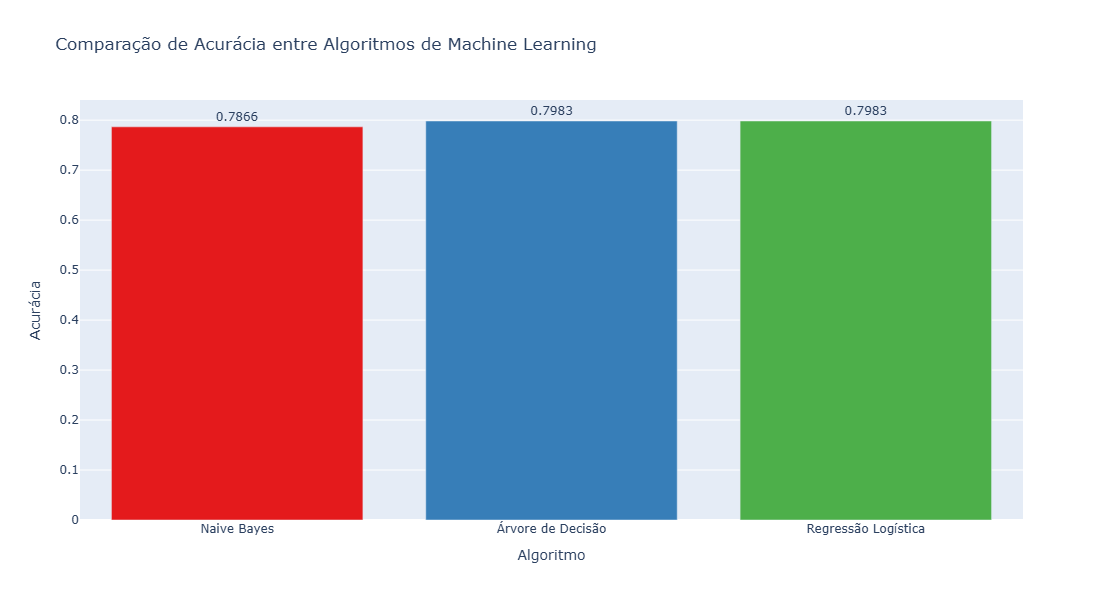

In [238]:
# Criando DataFrame para aplicar posteriormente no gráfico
dados = {
    "Algoritmo": ["Naive Bayes", "Árvore de Decisão", "Regressão Logística"],
    "Acurácia": [a, b, c]
}
df = pd.DataFrame(dados)

# Gráfico de barras
fig = px.bar(
    df,
    x="Algoritmo",
    y="Acurácia",
    text="Acurácia",
    title="Comparação de Acurácia entre Algoritmos de Machine Learning",
    color="Algoritmo",
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Ajustando layout do grafico
fig.update_layout(
    width=900,   # Largura da figura
    height=600,  # Altura da figura
    yaxis=dict(title='Acurácia'),
    xaxis=dict(title='Algoritmo'),
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    showlegend=False
)

fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')

fig.show()


Neste projeto, desenvolvemos e comparamos modelos de aprendizado de máquina com o objetivo de classificar automaticamente o sentimento dos clientes com base em transcrições de atendimento. Utilizando um conjunto robusto com mais de 550 mil registros, aplicamos técnicas de vetorização de texto combinadas com diferentes algoritmos de classificação.

O processo incluiu etapas de pré-processamento, como a vetorização das transcrições, e a escolha cuidadosa de parâmetros, o que contribuiu para o bom desempenho geral. No entanto, há sempre espaço para melhorias. Futuros aprimoramentos podem envolver ajustes finos nos parâmetros dos modelos, exploração de outras técnicas de pré-processamento e talvez até a combinação de modelos para alcançar uma maior precisão.

Foram avaliados quatro modelos principais:

Naive Bayes: rápido e eficiente, obteve uma acurácia de 0.7866, sendo uma boa opção base para dados textuais.

Árvore de Decisão (Decision Tree): alcançou 0.7983 de acurácia, oferecendo maior interpretabilidade e leve ganho de desempenho.

Regressão Logística: inserida como alternativa ao KNN, atingiu 0.7983 de acurácia — mesmo valor da Árvore de Decisão —, destacando-se por sua eficiência e robustez em grandes volumes de dados textuais.

Com base nos resultados, observamos que tanto a Regressão Logística quanto a Árvore de Decisão se mostraram modelos adequados para a tarefa, oferecendo equilíbrio entre desempenho e escalabilidade. A Regressão Logística, em especial, apresentou ótima performance mesmo com um volume elevado de dados, o que a torna uma excelente candidata para aplicações em ambiente de produção.

Este projeto demonstrou a eficácia de modelos tradicionais de machine learning na análise de sentimentos de textos e fornece uma base sólida para aplicações em ambientes reais, como atendimento ao cliente ou análise de feedback. Em futuras iterações, seria interessante explorar modelos mais complexos, como redes neurais ou técnicas de deep learning, para verificar se é possível melhorar ainda mais a performance.